In [1]:
# ============================================================
# LIBRARIAT
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Lexo dataset-in e pastruar
df = pd.read_csv("../data/processed/laliga_master.csv")

# Rendit sipas sezonit
df = df.sort_values(["sezoni", "Pts"], ascending=[True, False]).reset_index(drop=True)

print("Dimensionet:", df.shape)
print("OK!")

Dimensionet: (420, 33)
OK!


In [2]:
# ============================================================
# ELO RATING SYSTEM
# ============================================================

K = 32        # Sa shpejt ndryshon Elo
ELO_BAZE = 1000  # Elo fillestare per cdo ekip

def llogarit_elo_te_pritshme(elo_a, elo_b):
    """
    Probabiliteti i pritshëm i fitores së ekipit A
    """
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))

def perditeso_elo(elo_a, elo_b, rezultati_a):
    """
    rezultati_a: 1 = fitoi A, 0.5 = barazim, 0 = humbi A
    """
    e_a = llogarit_elo_te_pritshme(elo_a, elo_b)
    e_b = 1 - e_a

    elo_a_re = elo_a + K * (rezultati_a - e_a)
    elo_b_re = elo_b + K * ((1 - rezultati_a) - e_b)

    return elo_a_re, elo_b_re

print("Funksionet Elo u ngarkuan!")
print()
print("Shembull — Barcelona (1600) vs Getafe (1100):")
e = llogarit_elo_te_pritshme(1600, 1100)
print(f"Probabiliteti i fitores së Barcelona: {e:.3f} ({e*100:.1f}%)")

Funksionet Elo u ngarkuan!

Shembull — Barcelona (1600) vs Getafe (1100):
Probabiliteti i fitores së Barcelona: 0.947 (94.7%)


In [3]:
# ============================================================
# LLOGARIT ELO PER TE GJITHA SEZONED
# ============================================================

# Inicializo Elo per cdo ekip
elo_ratings = {}

historiku_elo = []

for sezoni in sorted(df["sezoni"].unique()):
    df_sezoni = df[df["sezoni"] == sezoni].sort_values("Pts", ascending=False).reset_index(drop=True)
    
    ekipet_sezoni = df_sezoni["Squad"].tolist()
    
    # Shto ekipet e reja me Elo bazë
    for ekip in ekipet_sezoni:
        if ekip not in elo_ratings:
            elo_ratings[ekip] = ELO_BAZE

    # Përditëso Elo bazuar në renditjen finale
    # Ekipi me më shumë pikë "fiton" ndaj secilit ekip poshtë tij
    for i in range(len(ekipet_sezoni)):
        for j in range(i + 1, len(ekipet_sezoni)):
            ekip_a = ekipet_sezoni[i]
            ekip_b = ekipet_sezoni[j]

            elo_a, elo_b = perditeso_elo(
                elo_ratings[ekip_a],
                elo_ratings[ekip_b],
                1  # Ekipi i lartë "fiton"
            )
            elo_ratings[ekip_a] = elo_a
            elo_ratings[ekip_b] = elo_b

    # Ruaj historikun
    for ekip in ekipet_sezoni:
        historiku_elo.append({
            "sezoni": sezoni,
            "Squad" : ekip,
            "elo"   : elo_ratings[ekip]
        })

df_elo = pd.DataFrame(historiku_elo)

print("=== ELO RATINGS FINALE (2024-2025) ===")
print(df_elo[df_elo["sezoni"] == "2024-2025"].sort_values("elo", ascending=False).to_string(index=False))

=== ELO RATINGS FINALE (2024-2025) ===
   sezoni           Squad         elo
2024-2025       Barcelona 1916.296364
2024-2025     Real Madrid 1894.524376
2024-2025 Atletico Madrid 1735.614599
2024-2025   Athletic Club 1448.467055
2024-2025      Villarreal 1435.891531
2024-2025      Real Betis 1407.933849
2024-2025   Real Sociedad 1325.950144
2024-2025         Osasuna 1215.391805
2024-2025      Celta Vigo 1192.110439
2024-2025        Valencia 1119.028587
2024-2025  Rayo Vallecano 1092.416264
2024-2025          Girona 1080.471126
2024-2025        Mallorca 1072.826616
2024-2025          Getafe 1027.802610
2024-2025         Sevilla 1004.587957
2024-2025          Alaves  944.021773
2024-2025        Espanyol  891.043800
2024-2025         Leganes  806.026186
2024-2025      Las Palmas  782.938271
2024-2025      Valladolid  687.164638


C:\Users\user\AppData\Local\Temp\ipykernel_13976\2920933623.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_elo["sezoni"].unique(),


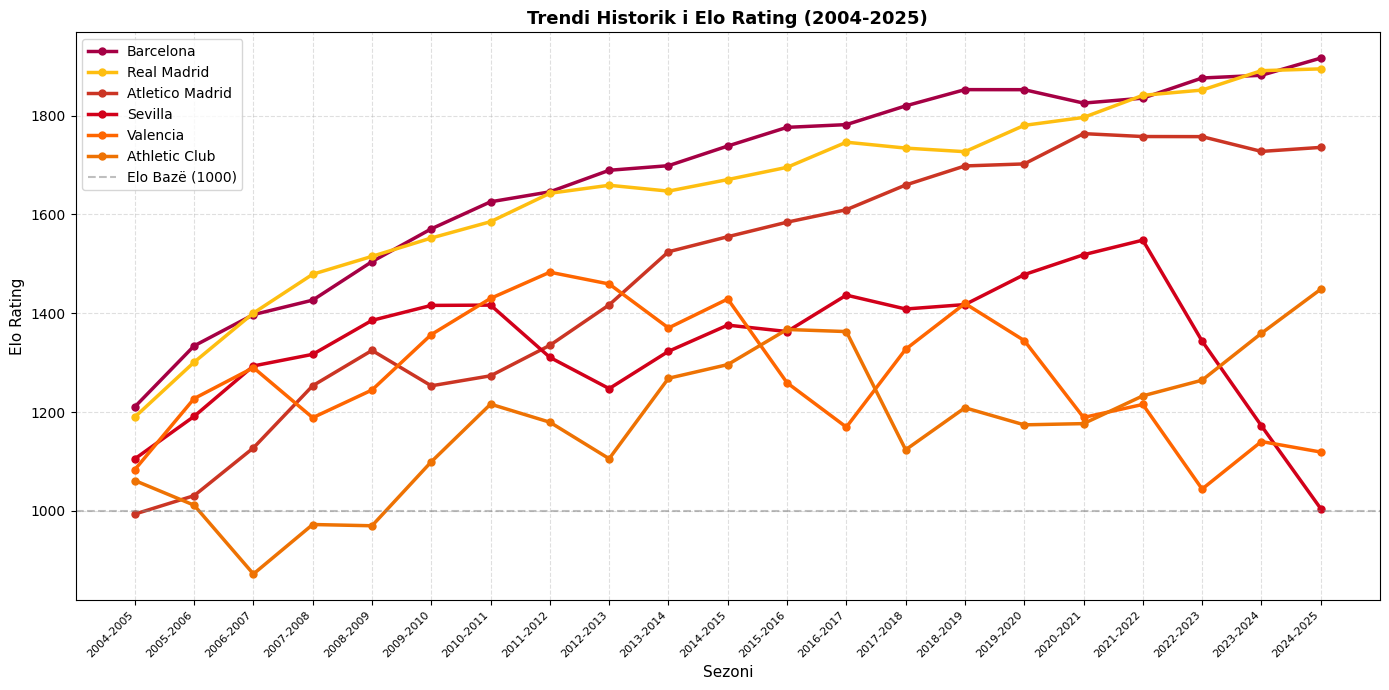

Grafiku u ruajt!


In [4]:
# ============================================================
# TRENDI HISTORIK I ELO
# ============================================================

ekipet_kryesore = ["Barcelona", "Real Madrid", "Atletico Madrid",
                   "Sevilla", "Valencia", "Athletic Club"]

ngjyrat = {
    "Barcelona"      : "#A50044",
    "Real Madrid"    : "#FEBE10",
    "Atletico Madrid": "#CB3524",
    "Sevilla"        : "#D2001A",
    "Valencia"       : "#FF6600",
    "Athletic Club"  : "#EE7203"
}

fig, ax = plt.subplots(figsize=(14, 7))

for ekip in ekipet_kryesore:
    df_ekip = df_elo[df_elo["Squad"] == ekip].sort_values("sezoni")
    ax.plot(df_ekip["sezoni"], df_ekip["elo"],
            color=ngjyrat[ekip], linewidth=2.5,
            marker="o", markersize=5, label=ekip)

ax.axhline(y=ELO_BAZE, color="gray", linestyle="--", 
           alpha=0.5, label="Elo Bazë (1000)")

ax.set_xlabel("Sezoni", fontsize=11)
ax.set_ylabel("Elo Rating", fontsize=11)
ax.set_title("Trendi Historik i Elo Rating (2004-2025)",
             fontsize=13, fontweight="bold")
ax.set_xticklabels(df_elo["sezoni"].unique(), 
                   rotation=45, ha="right", fontsize=8)
ax.legend(fontsize=10)
ax.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../outputs/figures/15_elo_trendi.png", dpi=150)
plt.show()

print("Grafiku u ruajt!")

In [9]:
# ============================================================
# PROBABILITETI I NDESHJES ME ELO — I RREGULLUAR
# ============================================================

# Elo finale per cdo ekip
elo_finale = df_elo[df_elo["sezoni"] == "2024-2025"].set_index("Squad")["elo"]

# Faktori i barazimit — historikisht ~25% e ndeshjeve barazohen
BARAZIM_FAKTOR = 0.25

ndeshjet = [
    ("Barcelona",       "Real Madrid"),
    ("Barcelona",       "Atletico Madrid"),
    ("Real Madrid",     "Atletico Madrid"),
    ("Barcelona",       "Athletic Club"),
    ("Real Madrid",     "Sevilla"),
    ("Atletico Madrid", "Sevilla"),
]

print("=== PROBABILITETI I FITORES (2024-2025) ===")
print(f"{'Ndeshja':45} {'Ekipi A':>10} {'Barazim':>10} {'Ekipi B':>10}")
print("-" * 85)

for ekip_a, ekip_b in ndeshjet:
    # Probabiliteti i pritshëm nga Elo
    e_a = llogarit_elo_te_pritshme(elo_finale[ekip_a], elo_finale[ekip_b])
    e_b = 1 - e_a

    # Zbrit barazi nga te dyja palet proporcionalisht
    p_barazim = BARAZIM_FAKTOR
    p_a = e_a * (1 - BARAZIM_FAKTOR)
    p_b = e_b * (1 - BARAZIM_FAKTOR)


    ndeshja = f"{ekip_a:20} vs {ekip_b:20}"
    print(f"{ndeshja:45} {p_a*100:>9.1f}% "
          f"{p_barazim*100:>9.1f}% "
          f"{p_b*100:>9.1f}% ")

=== PROBABILITETI I FITORES (2024-2025) ===
Ndeshja                                          Ekipi A    Barazim    Ekipi B
-------------------------------------------------------------------------------------
Barcelona            vs Real Madrid                39.8%      25.0%      35.2% 
Barcelona            vs Atletico Madrid            55.4%      25.0%      19.6% 
Real Madrid          vs Atletico Madrid            53.5%      25.0%      21.5% 
Barcelona            vs Athletic Club              70.2%      25.0%       4.8% 
Real Madrid          vs Sevilla                    74.6%      25.0%       0.4% 
Atletico Madrid      vs Sevilla                    73.9%      25.0%       1.1% 


In [10]:
# ============================================================
# EKSPORTO ELO PER PCA
# ============================================================

df_elo.to_csv("../data/processed/laliga_elo.csv", index=False)

print("U eksportua me sukses!")
print("Lokacioni: ../data/processed/laliga_elo.csv")
print("Dimensionet:", df_elo.shape)

U eksportua me sukses!
Lokacioni: ../data/processed/laliga_elo.csv
Dimensionet: (420, 3)
